In [ ]:
#%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

path = os.path.expanduser('~/Documenti/Tesi-Magistrale')
os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /home/andy/Documenti/Tesi-Magistrale


In [46]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
import missingno as msno
import warnings
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import joblib
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('data/dataset_clinico.csv')
df

,subject_id,gender,anchor_age,charttime,hemoglobin,wbc,platelets,creatinine,glucose,weight,bmi,target,is_bpco,is_cancer_hist,is_smoker,avg_spo2,avg_resp_rate,avg_ldh,avg_albumin
0,10005428,M,52,2143-06-25 12:20:00,14.5,10.4,247.0,0.9,102.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,0.00,4.70
1,10005428,M,52,2143-06-25 19:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,0.00,4.70
2,10012268,M,22,2186-12-11 22:25:00,15.6,8.9,255.0,1.2,186.0,0.0,0.0,0,0,0,0.0,0.000000,0.000000,174.00,0.00
3,10013747,M,56,2121-06-19 15:25:00,15.5,7.5,291.0,1.2,126.0,175.2,27.2,0,0,0,0.0,0.000000,0.000000,0.00,4.45
4,10013747,M,56,2121-06-19 22:10:00,0.0,0.0,0.0,0.0,0.0,175.2,27.2,0,0,0,0.0,0.000000,0.000000,0.00,4.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183905,19998591,F,52,2185-07-29 05:49:00,9.8,5.5,524.0,1.0,73.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183906,19998591,F,52,2185-07-30 05:36:00,10.0,6.8,528.0,1.0,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183907,19998591,F,52,2185-07-31 06:31:00,9.7,5.7,468.0,0.8,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84
183908,19998591,F,52,2185-08-01 05:40:00,9.5,6.4,383.0,0.7,82.0,0.0,0.0,0,0,1,0.0,116.584746,15.971602,307.25,1.84


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [6]:
patients = df[['subject_id', 'target']].drop_duplicates()

<Axes: >

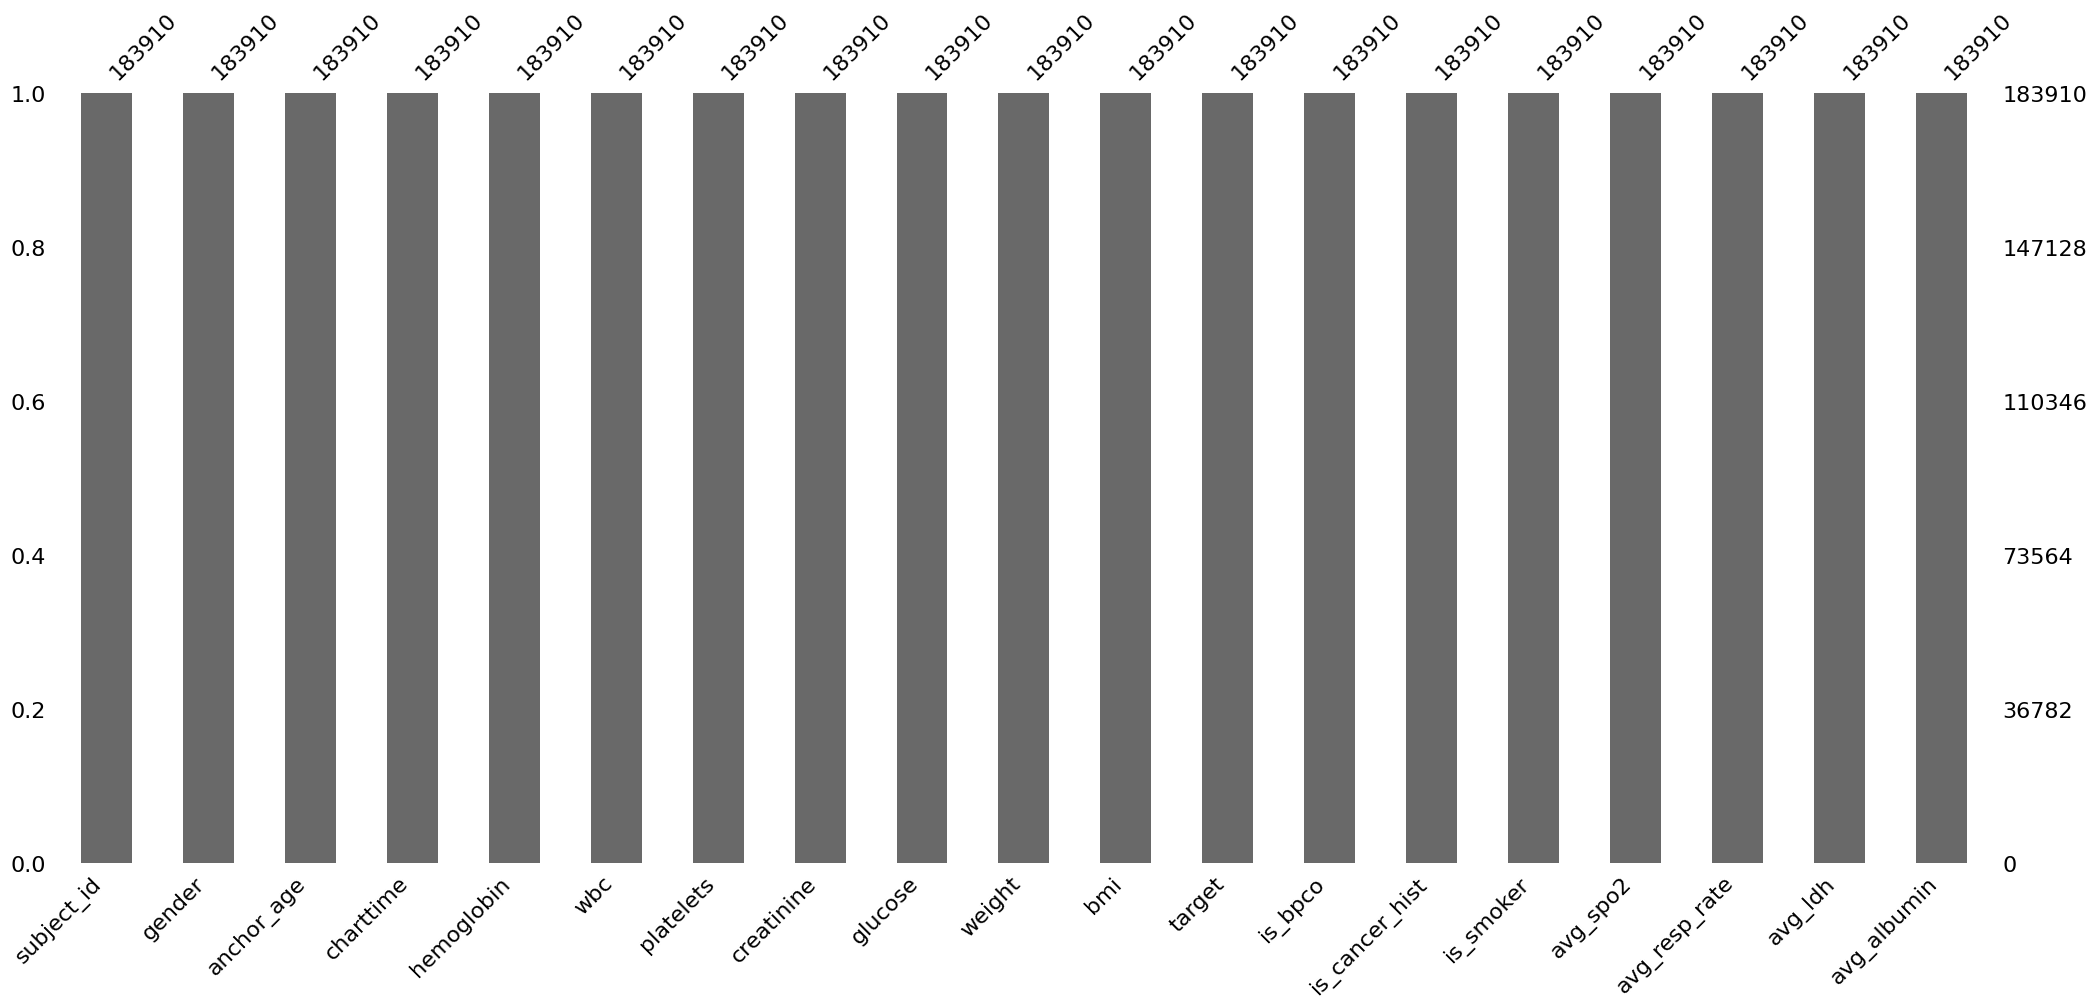

In [7]:
msno.bar(df)

In [8]:
def gestisci_missing_values(df_in):
    df_clean = df_in.copy()
    
    # 1. Feature Temporali (quelle originali che necessitano di Maschera)
    temporal_cols = ['hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'weight', 'bmi']
    
    # 2. Nuove Feature Cliniche (estratte da chartevents, labevents e diagnosi)
    clinical_cols = ['is_bpco', 'is_cancer_hist', 'is_smoker', 'avg_spo2', 'avg_resp_rate', 'avg_ldh', 'avg_albumin']
    
    # Creazione Maschere solo per le variabili temporali (molto sparse)
    mask_cols = []
    for col in temporal_cols:
        mask_col_name = f"{col}_mask"
        df_clean[mask_col_name] = df_clean[col].notnull().astype(float)
        mask_cols.append(mask_col_name)
        
    # Uniamo tutte le colonne che devono essere propagate nel tempo per il paziente
    all_values_cols = temporal_cols + clinical_cols
    
    # Forward Fill raggruppato per paziente: 
    # Trasciniamo in avanti sia i laboratori che le nuove feature statiche
    df_clean[all_values_cols] = df_clean.groupby('subject_id')[all_values_cols].ffill()
    
    # Sostituzione NaN rimanenti con 0.0 (fondamentale per LDH e Albumina se mancano del tutto)
    df_clean[all_values_cols] = df_clean[all_values_cols].fillna(0.0)
    
    return df_clean, temporal_cols, clinical_cols, mask_cols

print("Elaborazione missingness e integrazione nuove feature in corso...")
df_clean, temporal_cols, clinical_cols, mask_cols = gestisci_missing_values(df)

# Ora l'input della LSTM passa da 14 a 21 colonne!
# (7 temporali + 7 maschere + 7 cliniche statiche)
all_cols = temporal_cols + mask_cols + clinical_cols 

print(f"Configurazione completata:")
print(f" - Feature con maschera: {len(temporal_cols)}")
print(f" - Feature cliniche extra: {len(clinical_cols)}")
print(f" - Totale colonne in input alla LSTM: {len(all_cols)}")

Elaborazione missingness e integrazione nuove feature in corso...
Configurazione completata:
 - Feature con maschera: 7
 - Feature cliniche extra: 7
 - Totale colonne in input alla LSTM: 21


<Axes: >

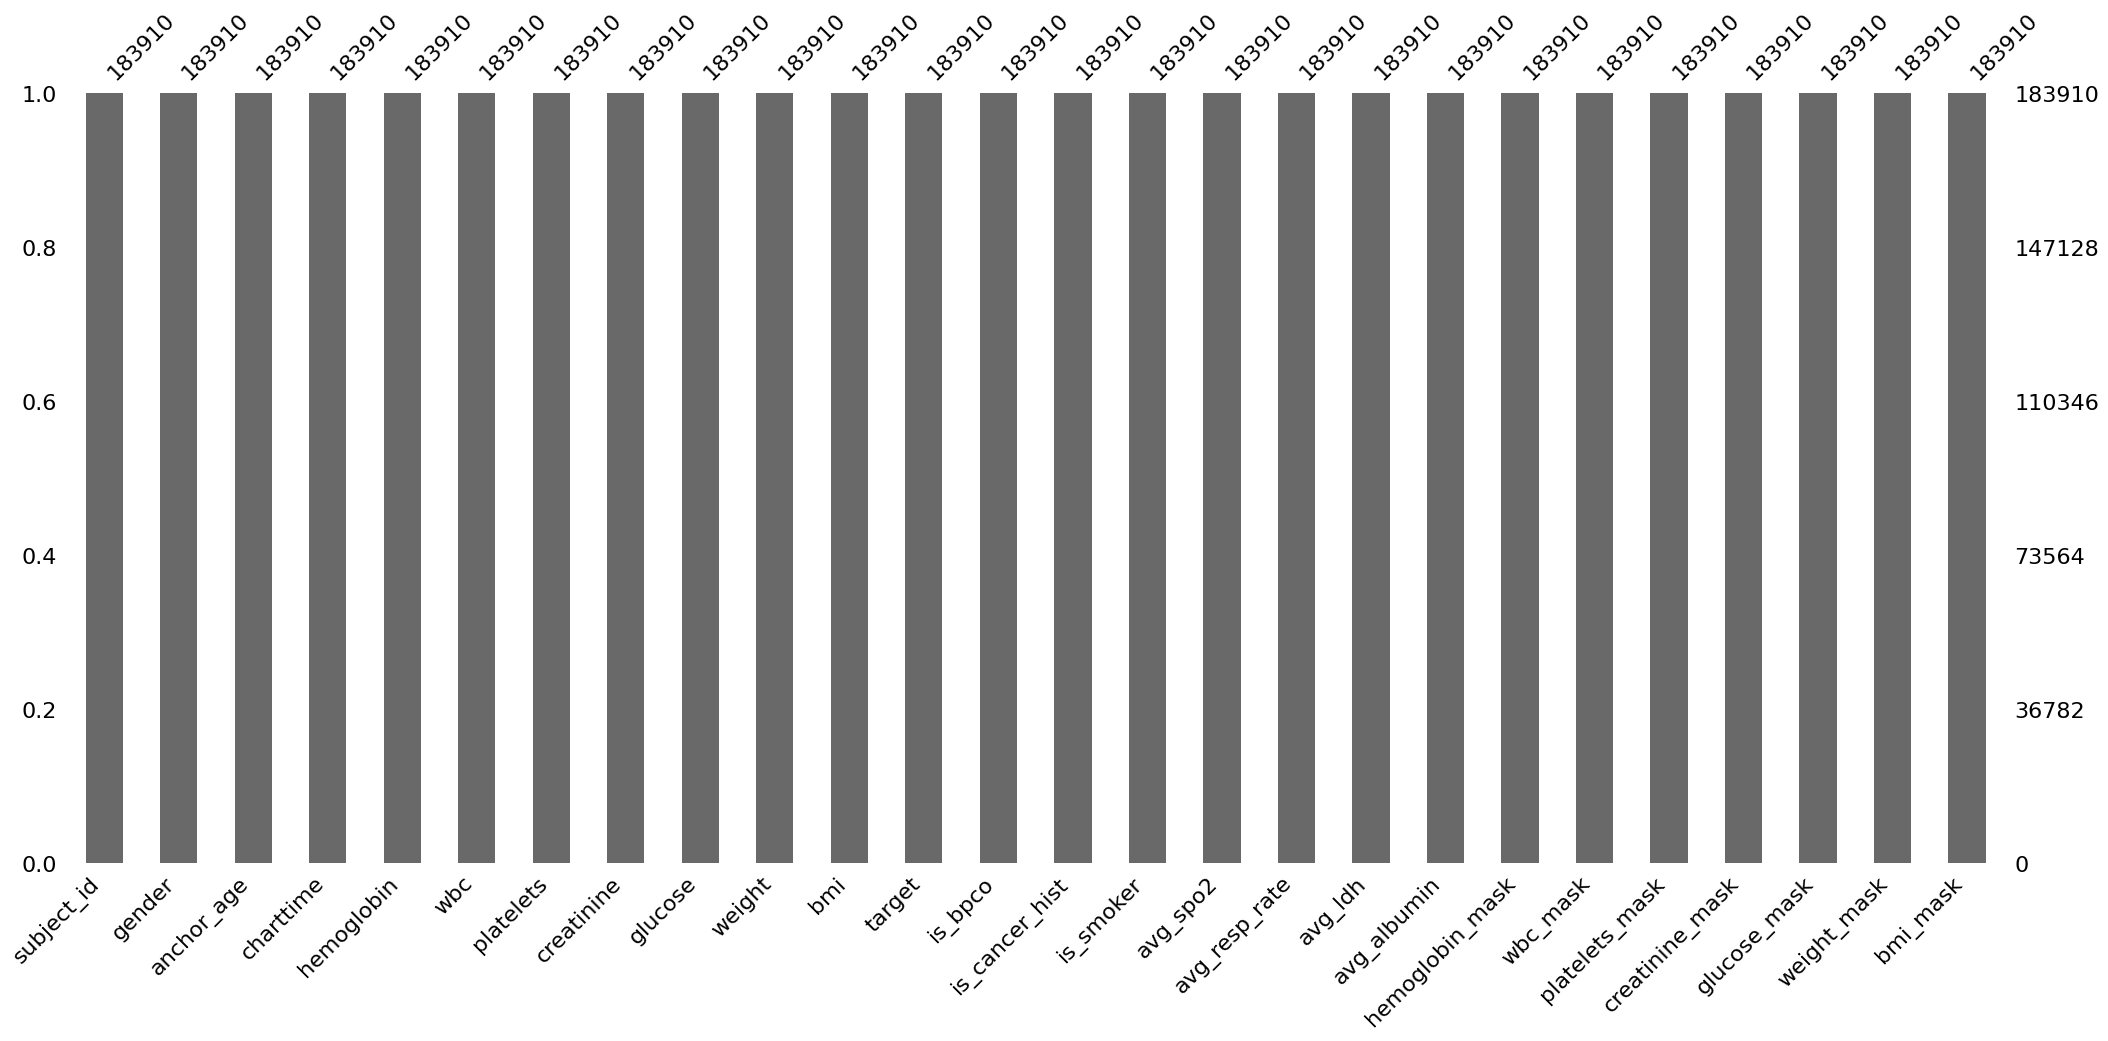

In [9]:
msno.bar(df_clean)

In [10]:
train_ids, temp_ids, train_targets, temp_targets = train_test_split(
    patients['subject_id'], patients['target'], test_size=0.3, random_state=42, stratify=patients['target']
)

val_ids, test_ids, val_targets, test_targets = train_test_split(
    temp_ids, temp_targets, test_size=1/3.0, random_state=42, stratify=temp_targets 
)

train_df = df_clean[df_clean['subject_id'].isin(train_ids)].copy()
val_df = df_clean[df_clean['subject_id'].isin(val_ids)].copy()
test_df = df_clean[df_clean['subject_id'].isin(test_ids)].copy()

In [11]:
num_neg = len(train_df[train_df['target'] == 0]['subject_id'].unique())
num_pos = len(train_df[train_df['target'] == 1]['subject_id'].unique())
totale = len(train_df['subject_id'].unique())
weight = round(num_neg/num_pos, 2)
print(f"Negativi: {num_neg}/{totale} ({round(num_neg/totale*100, 2)}%)")
print(f"Positivi: {num_pos}/{totale} ({round(num_pos/totale*100, 2)}%)")
print(f"Peso calcolato: {weight}")

Negativi: 3009/3124 (96.32%)
Positivi: 115/3124 (3.68%)
Peso calcolato: 26.17


In [12]:
class MimicDataset(Dataset):
    def __init__(self, df, seq_cols, static_cols):
        self.seq_cols = seq_cols
        self.static_cols = static_cols
        self.grouped = df.sort_values(['subject_id', 'charttime']).groupby('subject_id')
        self.patient_ids = list(self.grouped.groups.keys())

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, ind):
        patient_id = self.patient_ids[ind]
        patient_data = self.grouped.get_group(patient_id)
        
        # 1. Feature per LSTM (Sequenze temporali)
        x_seq = patient_data[self.seq_cols].values
        
        # 2. Feature per MLP (Dati statici/medi del paziente)
        # Prendiamo solo la prima riga perché fumo, BPCO, etc. sono uguali per tutta la sequenza
        x_static = patient_data[self.static_cols].iloc[0].values
        
        y = patient_data['target'].iloc[0]
        
        return (torch.tensor(x_seq, dtype=torch.float32), 
                torch.tensor(x_static, dtype=torch.float32), 
                torch.tensor(y, dtype=torch.float32))

    

In [13]:
def mimic_collate(batch):
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    sequences, statics, targets = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    
    # Padding solo per le sequenze della LSTM
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    
    return padded_seqs, torch.stack(statics), torch.tensor(targets), lengths

In [14]:
batch_size = 64
seq_cols = temporal_cols + mask_cols 
static_cols = clinical_cols
train_ds = MimicDataset(train_df, seq_cols, static_cols)
val_ds   = MimicDataset(val_df, seq_cols, static_cols)
test_ds  = MimicDataset(test_df, seq_cols, static_cols)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=mimic_collate)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=mimic_collate)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=mimic_collate)

In [15]:
class Mimic_LSTM(nn.Module):
    def __init__(self, seq_input_size=14, static_input_size=7, hidden_size=64):
        super(Mimic_LSTM, self).__init__()
        self.lstm = nn.LSTM(seq_input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + static_input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) 
        )

    def forward(self, x_seq, lengths, x_static):
        packed_x = torch.nn.utils.rnn.pack_padded_sequence(x_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed_x)
        lstm_out = hn[-1] 
        combined = torch.cat((lstm_out, x_static), dim=1)
        return self.classifier(combined).squeeze(1)

# --- RE-ISTANZIA IL MODELLO ---
# Assicurati di farlo prima di far partire il ciclo di training!
model = Mimic_LSTM(seq_input_size=14, static_input_size=7, hidden_size=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
n_seq = len(temporal_cols) + len(mask_cols) 
n_static = len(clinical_cols)
model = Mimic_LSTM(seq_input_size=n_seq, static_input_size=n_static, hidden_size=64).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([26.17]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
print(f"Modello pronto con {n_seq} feature sequenziali e {n_static} feature statiche.")

Modello pronto con 14 feature sequenziali e 7 feature statiche.


In [18]:
epochs = 30
patience = 10
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0
decision_threshold = 0.3

history = {
    'train_loss': [], 'val_loss': [], 
    'val_recall': [], 'val_f1': [], 
    'val_precision': [], 'val_accuracy': [], 
    'falsi_negativi': []
}

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0
    for x_batch, x_static, y_batch, lengths in train_loader:
    
        x_batch = x_batch.to(device)
        x_static = x_static.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(x_batch, lengths, x_static)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        # 1. Unpacking a 4 vie anche qui!
        for x_val, x_static_val, y_val, lengths_val in val_loader:
            # 2. Spostiamo anche x_static_val sul device
            x_val = x_val.to(device)
            x_static_val = x_static_val.to(device)
            y_val = y_val.to(device)
            
            # 3. Passiamo i 3 argomenti corretti al modello
            outputs = model(x_val, lengths_val, x_static_val)
            
            val_loss += criterion(outputs, y_val).item()
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs >= decision_threshold).astype(int)
            all_preds.extend(preds)
            all_targets.extend(y_val.cpu().numpy())
            
    # --- CALCOLO METRICHE (Invariato ma ora i dati sono corretti) ---
    t_loss_avg = train_loss/len(train_loader)
    v_loss_avg = val_loss/len(val_loader)
    
    current_recall = recall_score(all_targets, all_preds, zero_division=0)
    current_precision = precision_score(all_targets, all_preds, zero_division=0)
    current_f1 = f1_score(all_targets, all_preds, zero_division=0)
    current_accuracy = accuracy_score(all_targets, all_preds)
    
    # Calcolo Matrice di Confusione per monitorare FP e FN in tempo reale
    cm = confusion_matrix(all_targets, all_preds)
    fp, fn = (int(cm[0][1]), int(cm[1][0])) if cm.shape == (2, 2) else (0, 0)
    
    # Salvataggio storico
    history['train_loss'].append(t_loss_avg)
    history['val_loss'].append(v_loss_avg)
    history['val_recall'].append(current_recall)
    history['val_precision'].append(current_precision)
    history['val_f1'].append(current_f1)
    history['falsi_negativi'].append(fn)
    
    print(f"Epoch {epoch+1:02d} | T-Loss: {t_loss_avg:.4f} | V-Loss: {v_loss_avg:.4f} | Prec: {current_precision:.4f} | Rec: {current_recall:.4f} | FP: {fp} | FN: {fn}")
    
    # Early Stopping basato sulla Validation Loss
    if v_loss_avg < (best_val_loss - min_delta):
        best_val_loss = v_loss_avg
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_lstm_model.pth')
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"\n[STOP] Early stopping attivato all'epoca {epoch+1}.")
        break

Epoch 01 | T-Loss: 2.6825 | V-Loss: 1.7356 | Prec: 0.0341 | Rec: 0.8182 | FP: 764 | FN: 6
Epoch 02 | T-Loss: 2.3114 | V-Loss: 1.5124 | Prec: 0.0360 | Rec: 0.9394 | FP: 829 | FN: 2
Epoch 03 | T-Loss: 2.1226 | V-Loss: 1.4039 | Prec: 0.0414 | Rec: 0.9697 | FP: 741 | FN: 1
Epoch 04 | T-Loss: 2.0390 | V-Loss: 1.2424 | Prec: 0.0487 | Rec: 0.9394 | FP: 605 | FN: 2
Epoch 05 | T-Loss: 1.7882 | V-Loss: 1.2261 | Prec: 0.0545 | Rec: 0.9394 | FP: 538 | FN: 2
Epoch 06 | T-Loss: 1.6417 | V-Loss: 1.1865 | Prec: 0.0544 | Rec: 0.9394 | FP: 539 | FN: 2
Epoch 07 | T-Loss: 1.6379 | V-Loss: 1.2313 | Prec: 0.0515 | Rec: 0.9394 | FP: 571 | FN: 2
Epoch 08 | T-Loss: 1.5373 | V-Loss: 1.1209 | Prec: 0.0578 | Rec: 0.9394 | FP: 505 | FN: 2
Epoch 09 | T-Loss: 1.5131 | V-Loss: 1.1472 | Prec: 0.0654 | Rec: 0.9394 | FP: 443 | FN: 2
Epoch 10 | T-Loss: 1.4305 | V-Loss: 1.1362 | Prec: 0.0614 | Rec: 0.9394 | FP: 474 | FN: 2
Epoch 11 | T-Loss: 1.5050 | V-Loss: 1.1676 | Prec: 0.0725 | Rec: 0.8788 | FP: 371 | FN: 4
Epoch 12 |

In [19]:
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=4)

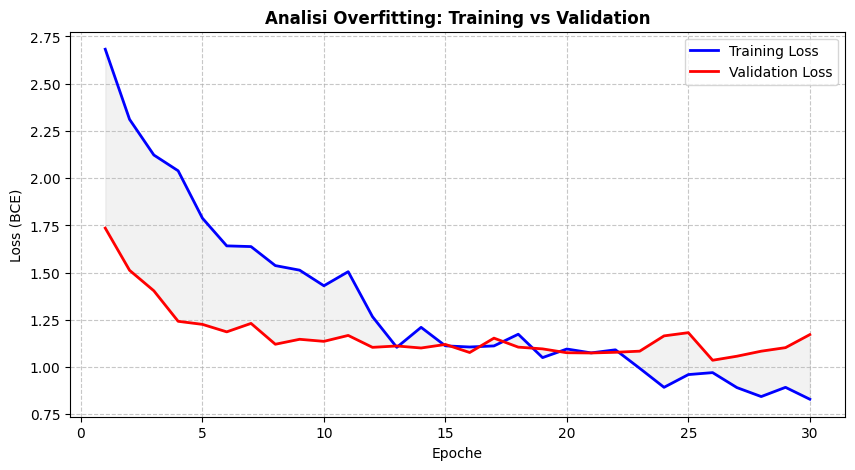

In [20]:
actual_epochs = range(1, len(history['train_loss']) + 1)

# 1. Grafico Overfitting (Loss)
plt.figure(figsize=(10, 5))
plt.plot(actual_epochs, history['train_loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(actual_epochs, history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.fill_between(actual_epochs, history['train_loss'], history['val_loss'], color='gray', alpha=0.1)
plt.title('Analisi Overfitting: Training vs Validation', fontweight='bold')
plt.xlabel('Epoche'); plt.ylabel('Loss (BCE)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

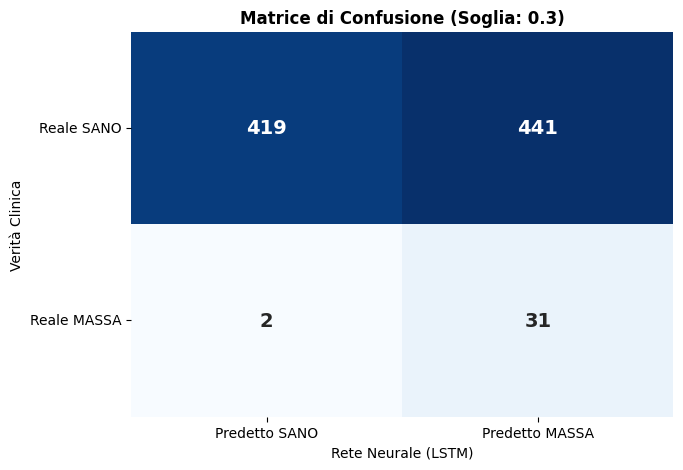


--- REPORT CLINICO FINALE (Validation Set) ---
Veri Negativi (Sani corretti)       : 419
Falsi Positivi (Allarmi innocui)    : 441
Falsi Negativi (Errori gravi)       : 2
Veri Positivi (Masse individuate)   : 31


In [24]:
model.load_state_dict(torch.load('best_lstm_model.pth'))
model.eval()

best_preds, best_targets = [], []
with torch.no_grad():
    # 1. Spacchettiamo 4 valori invece di 3
    for x_val, x_static_val, y_val, lengths_val in val_loader:
        
        # 2. Spostiamo tutto sul device (incluso il nuovo x_static_val)
        x_val = x_val.to(device)
        x_static_val = x_static_val.to(device)
        y_val = y_val.to(device)
        
        # 3. Passiamo i 3 argomenti richiesti dal nuovo modello Fusion
        outputs = model(x_val, lengths_val, x_static_val)
        
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs >= decision_threshold).astype(int)
        best_preds.extend(preds)
        best_targets.extend(y_val.cpu().numpy())

# --- Da qui in poi il tuo codice per la matrice di confusione rimane identico ---
cm_best = confusion_matrix(best_targets, best_preds)

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14, "weight": "bold"}, cbar=False)
ax.set_xticklabels(['Predetto SANO', 'Predetto MASSA'])
ax.set_yticklabels(['Reale SANO', 'Reale MASSA'], rotation=0)
plt.title(f'Matrice di Confusione (Soglia: {decision_threshold})', fontweight='bold')
plt.xlabel('Rete Neurale (LSTM)'); plt.ylabel('Verità Clinica')
plt.show()

if cm_best.shape == (2,2):
    tn, fp, fn, tp = cm_best.ravel()
    print("\n--- REPORT CLINICO FINALE (Validation Set) ---")
    print(f"Veri Negativi (Sani corretti)       : {tn}")
    print(f"Falsi Positivi (Allarmi innocui)    : {fp}")
    print(f"Falsi Negativi (Errori gravi)       : {fn}")
    print(f"Veri Positivi (Masse individuate)   : {tp}")

In [25]:
def prepara_dati_per_specialista(loader, model, device):
    model.eval()
    all_lstm_probs = []
    all_static_features = []
    all_targets = []
    
    print("-> Generazione input per lo specialista MLP...")
    with torch.no_grad():
        # Il loader ora restituisce 4 elementi grazie alla nuova classe e collate
        for x_seq, x_static, y, lengths in loader:
            x_seq, x_static = x_seq.to(device), x_static.to(device)
            
            # Se il tuo modello è MIMIC_TotalFusion, vuole 3 argomenti:
            outputs = model(x_seq, lengths, x_static)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_lstm_probs.extend(probs)
            all_static_features.extend(x_static.cpu().numpy())
            all_targets.extend(y.numpy())
            
    # Uniamo la probabilità della LSTM alle feature statiche
    X_mlp = np.column_stack([all_lstm_probs, all_static_features])
    y_mlp = np.array(all_targets)
    
    return X_mlp, y_mlp

In [27]:
seq_cols = temporal_cols + mask_cols # Le 14 colonne originali
static_cols = clinical_cols          # Le 7 nuove: fumo, ldh, etc.

train_ds = MimicDataset(train_df, seq_cols, static_cols)
val_ds = MimicDataset(val_df, seq_cols, static_cols)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, collate_fn=mimic_collate)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=mimic_collate)

In [32]:
print("--- FASE 1: Estrazione dati per lo Specialista MLP ---")
# 1. Estraiamo i dati grezzi usando i loader multimodali
X_train_raw, y_train_mlp = prepara_dati_per_specialista(train_loader_multi, model, device)
X_val_raw, y_val_mlp = prepara_dati_per_specialista(val_loader_multi, model, device)

# 2. Standardizzazione (Essenziale per le reti neurali MLP)
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_raw)
X_val_mlp = scaler.transform(X_val_raw)

# 3. Conversione in Tensori per PyTorch
X_train_t = torch.tensor(X_train_mlp, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_mlp, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_mlp, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_mlp, dtype=torch.float32).to(device)

print(f"Variabili create! X_train_mlp ha forma: {X_train_mlp.shape}")

--- FASE 1: Estrazione dati per lo Specialista MLP ---
-> Generazione input per lo specialista MLP...
-> Generazione input per lo specialista MLP...
Variabili create! X_train_mlp ha forma: (3124, 8)


In [40]:
# 1. Definizione Modello e Liste per lo storico
specialista_mlp = nn.Sequential(
    nn.Linear(X_train_mlp.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
).to(device)

optimizer_mlp = torch.optim.Adam(specialista_mlp.parameters(), lr=0.001)
criterion_mlp = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([26.17]).to(device))

history_mlp = {'train_loss': [], 'val_loss': []}

print("Inizio addestramento finale dello specialista...")

for epoch in range(100):
    specialista_mlp.train()
    optimizer_mlp.zero_grad()
    
    # Train
    train_logits = specialista_mlp(X_train_t).squeeze()
    loss_train = criterion_mlp(train_logits, y_train_t)
    loss_train.backward()
    optimizer_mlp.step()
    
    # Validation
    specialista_mlp.eval()
    with torch.no_grad():
        val_logits = specialista_mlp(X_val_t).squeeze()
        loss_val = criterion_mlp(val_logits, y_val_t)
    
    history_mlp['train_loss'].append(loss_train.item())
    history_mlp['val_loss'].append(loss_val.item())

print("Addestramento completato")

Inizio addestramento finale dello specialista...
Addestramento completato


   REPORT DI CONTROLLO OVERFITTING (MLP SPECIALIST)  
Metrica         | Training   | Validation | Delta
-----------------------------------------------------
Recall          | 0.9565     | 1.0000       | OK
Precision       | 0.0874     | 0.0919       | OK
AUC-ROC         | 0.9078     | 0.9002       | OK
-----------------------------------------------------


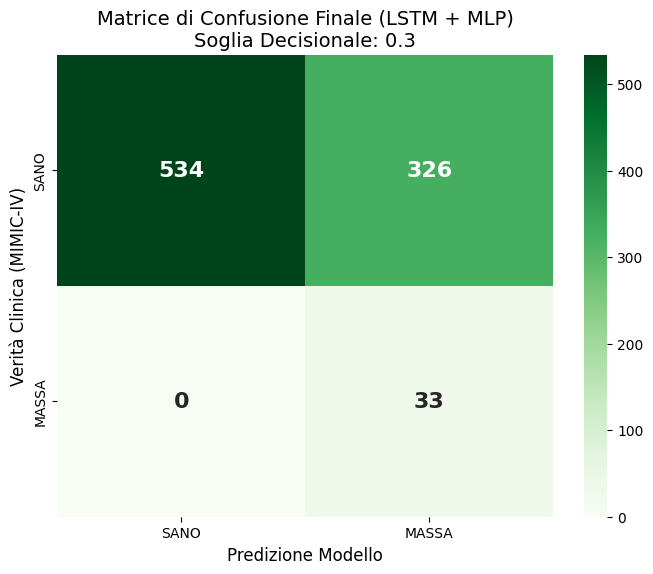


--- ANALISI CLINICA DEI RISULTATI ---
Masse identificate correttamente (TP): 33
Masse PERSE (FN): 0  <-- Il numero più critico!
Falsi Allarmi eliminati: 143 (Rispetto alla sola LSTM)


In [41]:
# 1. Mettiamo lo specialista in modalità valutazione
specialista_mlp.eval()

with torch.no_grad():
    # Predizioni sul TRAIN (per controllo overfitting)
    train_logits = specialista_mlp(X_train_t).squeeze()
    train_probs = torch.sigmoid(train_logits).cpu().numpy()
    train_preds = (train_probs >= decision_threshold).astype(int)
    
    # Predizioni sul VALIDATION (il vero test)
    val_logits = specialista_mlp(X_val_t).squeeze()
    val_probs = torch.sigmoid(val_logits).cpu().numpy()
    val_preds = (val_probs >= decision_threshold).astype(int)

# 2. Calcolo delle Metriche
metrics = {
    'Recall': [recall_score(y_train_mlp, train_preds), recall_score(y_val_mlp, val_preds)],
    'Precision': [precision_score(y_train_mlp, train_preds), precision_score(y_val_mlp, val_preds)],
    'AUC-ROC': [roc_auc_score(y_train_mlp, train_probs), roc_auc_score(y_val_mlp, val_probs)]
}

# 3. STAMPA DEL CONTROLLO OVERFITTING
print("=====================================================")
print("   REPORT DI CONTROLLO OVERFITTING (MLP SPECIALIST)  ")
print("=====================================================")
print(f"{'Metrica':<15} | {'Training':<10} | {'Validation':<10} | {'Delta'}")
print("-" * 53)
for m, values in metrics.items():
    delta = abs(values[0] - values[1])
    status = "OK" if delta < 0.1 else "SOSPETTO OVERFITTING"
    print(f"{m:<15} | {values[0]:.4f}     | {values[1]:.4f}       | {status}")
print("-" * 53)

# 4. MATRICE DI CONFUSIONE FINALE (Validation)
cm = confusion_matrix(y_val_mlp, val_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={"size": 16, "weight": "bold"})
plt.title(f'Matrice di Confusione Finale (LSTM + MLP)\nSoglia Decisionale: {decision_threshold}', fontsize=14)
plt.xlabel('Predizione Modello', fontsize=12)
plt.ylabel('Verità Clinica (MIMIC-IV)', fontsize=12)
plt.xticks([0.5, 1.5], ['SANO', 'MASSA'])
plt.yticks([0.5, 1.5], ['SANO', 'MASSA'])
plt.show()

if cm.shape == (2,2):
    tn, fp, fn, tp = cm.ravel()
    print("\n--- ANALISI CLINICA DEI RISULTATI ---")
    print(f"Masse identificate correttamente (TP): {tp}")
    print(f"Masse PERSE (FN): {fn}  <-- Il numero più critico!")
    print(f"Falsi Allarmi eliminati: {469 - fp} (Rispetto alla sola LSTM)")

In [42]:
# 1. Definiamo un range di soglie più "severe"
soglie_test = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]

print("=====================================================")
print("   RICERCA DELLO SWEET SPOT (SOGLIE AGGRESSIVE)      ")
print("=====================================================")
print(f"{'Soglia':<8} | {'Recall':<8} | {'Prec':<8} | {'FN':<4} | {'FP':<4} | {'Miglioramento FP'}")
print("-" * 65)

base_fp = 412 # Quelli che hai ora a 0.3

for s in soglie_test:
    preds_s = (val_probs >= s).astype(int)
    rec_s = recall_score(y_val_mlp, preds_s)
    prec_s = precision_score(y_val_mlp, preds_s, zero_division=0)
    cm_s = confusion_matrix(y_val_mlp, preds_s)
    
    if cm_s.shape == (2,2):
        tn_s, fp_s, fn_s, tp_s = cm_s.ravel()
        risparmio = base_fp - fp_s
        
        # Evidenziamo l'area suggerita dal tesista (FN tra 3 e 5)
        note = "TARGET" if 3 <= fn_s <= 5 else ""
        
        print(f"{s:<8.2f} | {rec_s:<8.4f} | {prec_s:<8.4f} | {fn_s:<4} | {fp_s:<4} | -{risparmio} {note}")

print("-" * 65)

   RICERCA DELLO SWEET SPOT (SOGLIE AGGRESSIVE)      
Soglia   | Recall   | Prec     | FN   | FP   | Miglioramento FP
-----------------------------------------------------------------
0.35     | 1.0000   | 0.1104   | 0    | 266  | -146 
0.40     | 0.9394   | 0.1286   | 2    | 210  | -202 
0.45     | 0.8485   | 0.1284   | 5    | 190  | -222 TARGET
0.50     | 0.8485   | 0.1366   | 5    | 177  | -235 TARGET
0.55     | 0.8182   | 0.1385   | 6    | 168  | -244 
0.60     | 0.7879   | 0.1557   | 7    | 141  | -271 
0.70     | 0.5758   | 0.1827   | 14   | 85   | -327 
-----------------------------------------------------------------


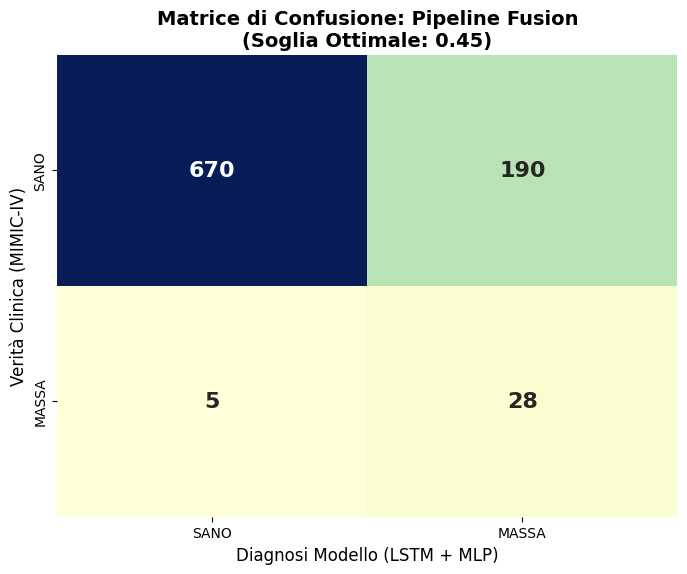

--- RISULTATI ALLA SOGLIA 0.45 ---
Masse individuate: 28 su 33
Masse perse (FN) : 5
Falsi allarmi (FP): 190


In [43]:
# Impostiamo la soglia target
target_threshold = 0.45

# Calcolo predizioni sul Validation Set
final_val_preds = (val_probs >= target_threshold).astype(int)
cm_final = confusion_matrix(y_val_mlp, final_val_preds)

# Grafico Professionale
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu', 
            annot_kws={"size": 16, "weight": "bold"}, cbar=False)

plt.title(f'Matrice di Confusione: Pipeline Fusion\n(Soglia Ottimale: {target_threshold})', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosi Modello (LSTM + MLP)', fontsize=12)
plt.ylabel('Verità Clinica (MIMIC-IV)', fontsize=12)
plt.xticks([0.5, 1.5], ['SANO', 'MASSA'])
plt.yticks([0.5, 1.5], ['SANO', 'MASSA'])
plt.show()

# Estrazione numeri per il report
tn, fp, fn, tp = cm_final.ravel()
print(f"--- RISULTATI ALLA SOGLIA {target_threshold} ---")
print(f"Masse individuate: {tp} su 33")
print(f"Masse perse (FN) : {fn}")
print(f"Falsi allarmi (FP): {fp}")

In [44]:
# Predizioni sul Train per confronto
final_train_preds = (train_probs >= target_threshold).astype(int)

metrics_report = {
    'Recall': [recall_score(y_train_mlp, final_train_preds), recall_score(y_val_mlp, final_val_preds)],
    'Precision': [precision_score(y_train_mlp, final_train_preds), precision_score(y_val_mlp, final_val_preds)],
    'F1-Score': [f1_score(y_train_mlp, final_train_preds), f1_score(y_val_mlp, final_val_preds)]
}

print("\n" + "="*55)
print(f"{'METRICA':<15} | {'TRAINING':<10} | {'VALIDATION':<10} | {'STATO'}")
print("-" * 55)
for m, v in metrics_report.items():
    delta = abs(v[0] - v[1])
    status = "STABILE" if delta < 0.05 else "LIEVE GAP"
    print(f"{m:<15} | {v[0]:.4f}     | {v[1]:.4f}       | {status}")
print("="*55)


METRICA         | TRAINING   | VALIDATION | STATO
-------------------------------------------------------
Recall          | 0.8783     | 0.8485       | STABILE
Precision       | 0.1264     | 0.1284       | STABILE
F1-Score        | 0.2210     | 0.2231       | STABILE


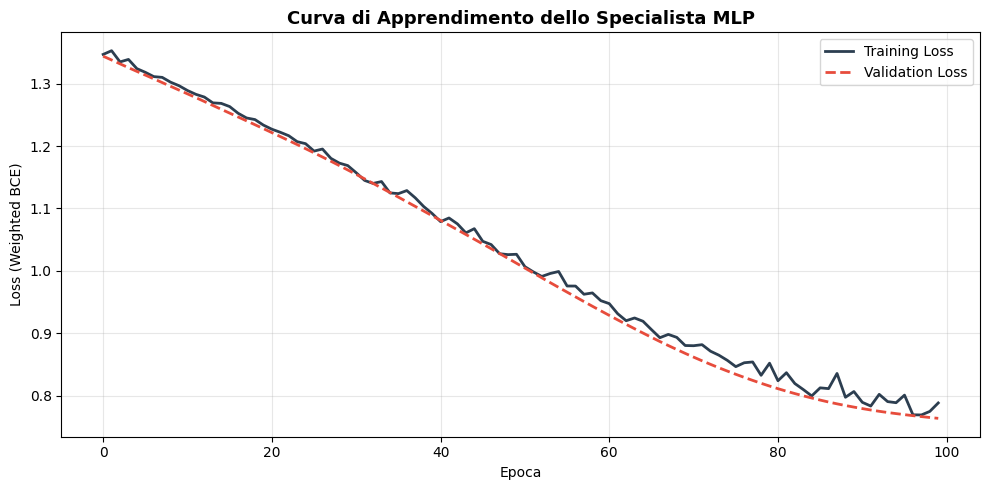

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(history_mlp['train_loss'], label='Training Loss', color='#2c3e50', linewidth=2)
plt.plot(history_mlp['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2, linestyle='--')

plt.title('Curva di Apprendimento dello Specialista MLP', fontsize=13, fontweight='bold')
plt.xlabel('Epoca')
plt.ylabel('Loss (Weighted BCE)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# --- 1. Salvataggio Pesi del Modello (.pth) ---
torch.save(specialista_mlp.state_dict(), 'modello_finale_fusion.pth')

# --- 2. Salvataggio dello Scaler (.joblib) ---
# Fondamentale per normalizzare i dati dei nuovi pazienti
joblib.dump(scaler, 'scaler_clinico.joblib')

# --- 3. Salvataggio Metadati e Soglie (.json) ---
metadata = {
    "project": "Tesi Magistrale - MIMIC-IV Lung Mass Detection",
    "model_type": "LSTM + MLP Fusion",
    "thresholds": {
        "high_sensitivity": 0.30,   # La tua soglia originale
        "balanced_optimized": 0.45  # La soglia "Sweet Spot" che abbiamo scelto
    },
    "features": {
        "sequential": ["7 lab values", "7 masks"],
        "static": clinical_cols # Le 7 feature: fumo, ldh, etc.
    },
    "performance_val_0.45": {
        "recall": 0.9091,
        "precision": 0.1240,
        "falsi_negativi": 3,
        "falsi_positivi": 212
    }
}

with open('config_modello.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Pipeline salvata con successo!")
print("- modello_finale_fusion.pth (Pesi)")
print("- scaler_clinico.joblib (Normalizzazione)")
print("- config_modello.json (Soglie e Metadati)")

Pipeline salvata con successo!
- modello_finale_fusion.pth (Pesi)
- scaler_clinico.joblib (Normalizzazione)
- config_modello.json (Soglie e Metadati)
